In [4]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Load Diabetes dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

# Features and binary target
X = df[['Glucose', 'BMI', 'Age']]
y = df['Outcome']

# Train/test split for binary classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Binary Logistic Regression
model_bin = LogisticRegression(max_iter=1000, random_state=42)
model_bin.fit(X_train_scaled, y_train)
y_pred_bin = model_bin.predict(X_test_scaled)
y_prob_bin = model_bin.predict_proba(X_test_scaled)[:, 1]

print("=== Binary Logistic Regression ===")
print(classification_report(y_test, y_pred_bin))
print("AUC:", roc_auc_score(y_test, y_prob_bin))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bin))

# Multinomial Logistic Regression (using AgeGroup as target)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, np.inf], labels=[0, 1, 2])
X_multi = df[['Glucose', 'BMI', 'Age']]
y_multi = df['AgeGroup']

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.3, stratify=y_multi, random_state=42
)

# Standardize features for multinomial regression
X_train_multi_scaled = scaler.fit_transform(X_train_multi)
X_test_multi_scaled = scaler.transform(X_test_multi)

model_multi = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42
)
model_multi.fit(X_train_multi_scaled, y_train_multi)
y_pred_multi = model_multi.predict(X_test_multi_scaled)
y_prob_multi = model_multi.predict_proba(X_test_multi_scaled)

print("\n=== Multinomial Logistic Regression (AgeGroup) ===")
print(classification_report(y_test_multi, y_pred_multi))
auc_multi = roc_auc_score(
    y_test_multi, y_prob_multi, multi_class='ovr', average='macro'
)
print("Multiclass AUC (macro-averaged):", auc_multi)
print("Confusion Matrix:\n", confusion_matrix(y_test_multi, y_pred_multi))

# Paired t-test: raw vs normalized Glucose
glucose_raw = df['Glucose']
glucose_norm = scaler.fit_transform(df[['Glucose']]).flatten()
t_stat, p_val = stats.ttest_rel(glucose_raw, glucose_norm)
print("\nPaired T-Test (Glucose raw vs normalized): t=%.3f, p=%.3g" % (t_stat, p_val))


=== Binary Logistic Regression ===
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.68      0.52      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.74      0.74      0.74       231

AUC: 0.8196707818930041
Confusion Matrix:
 [[130  20]
 [ 39  42]]

=== Multinomial Logistic Regression (AgeGroup) ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       126
           1       0.94      0.93      0.93        81
           2       1.00      0.79      0.88        24

    accuracy                           0.95       231
   macro avg       0.96      0.91      0.93       231
weighted avg       0.95      0.95      0.95       231

Multiclass AUC (macro-averaged): 0.9969994997462216
Confusion Matrix:
 [[126   0   0]
 [  6  75   0]
 [  0   5  19]]

Paired T-Test (Glucos

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [5]:
from sklearn.metrics import roc_auc_score

auc_multi = roc_auc_score(y_test_multi, y_prob_multi, multi_class='ovr', average='macro')
print("Multiclass AUC (macro-averaged):", auc_multi)

Multiclass AUC (macro-averaged): 0.9969994997462216


In [6]:
from sklearn.metrics import accuracy_score

accuracy_multi = accuracy_score(y_test_multi, y_pred_multi)
print("Accuracy (Multinomial Logistic Regression, AgeGroup):", accuracy_multi)

Accuracy (Multinomial Logistic Regression, AgeGroup): 0.9523809523809523


In [7]:
from sklearn.metrics import accuracy_score

accuracy_bin = accuracy_score(y_test, y_pred_bin)
print("Accuracy (Binary Logistic Regression):", accuracy_bin)

Accuracy (Binary Logistic Regression): 0.7445887445887446


In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Calculate metrics for each AgeGroup class
precision = precision_score(y_test_multi, y_pred_multi, average=None, labels=[0, 1, 2])
recall = recall_score(y_test_multi, y_pred_multi, average=None, labels=[0, 1, 2])
f1 = f1_score(y_test_multi, y_pred_multi, average=None, labels=[0, 1, 2])
accuracy = accuracy_score(y_test_multi, y_pred_multi)

# Prepare table data
rows = []
for i, label in enumerate([0, 1, 2]):
    row = [
        f"AgeGroup {label}",
        f"{precision[i]:.2f}",
        f"{recall[i]:.2f}",
        f"{f1[i]:.2f}",
        f"{accuracy:.2f}" if label == 0 else "—"
    ]
    rows.append(row)

# Print table
header = ["Metric", "Precision", "Recall", "F1-Score", "Accuracy"]
print("{:<12} {:<10} {:<10} {:<10} {:<10}".format(*header))
for row in rows:
    print("{:<12} {:<10} {:<10} {:<10} {:<10}".format(*row))

Metric       Precision  Recall     F1-Score   Accuracy  
AgeGroup 0   0.95       1.00       0.98       0.95      
AgeGroup 1   0.94       0.93       0.93       —         
AgeGroup 2   1.00       0.79       0.88       —         


In [13]:
# The accuracy for Multinomial Logistic Regression (AgeGroup) is already calculated as 'accuracy' in previous cells.
print("Accuracy (Multinomial Logistic Regression, AgeGroup):", accuracy)

Accuracy (Multinomial Logistic Regression, AgeGroup): 0.9523809523809523


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats

from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

# Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

# Binary classification setup
X = df[['Glucose', 'BMI', 'Age']]
y = df['Outcome']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Binary Logistic Regression
model_bin = LogisticRegression(max_iter=1000, random_state=42)
model_bin.fit(X_train_scaled, y_train)
y_pred_bin = model_bin.predict(X_test_scaled)
y_prob_bin = model_bin.predict_proba(X_test_scaled)[:, 1]

print("=== Binary Logistic Regression ===")
print(classification_report(y_test, y_pred_bin))
print("AUC:", roc_auc_score(y_test, y_prob_bin))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bin))
print("Accuracy:", accuracy_score(y_test, y_pred_bin))

# Multinomial classification: AgeGroup
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 30, 50, np.inf], labels=[0, 1, 2])
X_multi = df[['Glucose', 'BMI', 'Age']]
y_multi = df['AgeGroup']

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.3, stratify=y_multi, random_state=42
)

X_train_multi_scaled = scaler.fit_transform(X_train_multi)
X_test_multi_scaled = scaler.transform(X_test_multi)

model_multi = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42
)
model_multi.fit(X_train_multi_scaled, y_train_multi)
y_pred_multi = model_multi.predict(X_test_multi_scaled)
y_prob_multi = model_multi.predict_proba(X_test_multi_scaled)

print("\n=== Multinomial Logistic Regression (AgeGroup) ===")
print(classification_report(y_test_multi, y_pred_multi))
print("Confusion Matrix:\n", confusion_matrix(y_test_multi, y_pred_multi))
print("Accuracy:", accuracy_score(y_test_multi, y_pred_multi))
print("AUC (macro):", roc_auc_score(
    y_test_multi, y_prob_multi, multi_class='ovr', average='macro'
))

# Per-class metrics for AgeGroup
precision = precision_score(y_test_multi, y_pred_multi, average=None, labels=[0, 1, 2])
recall = recall_score(y_test_multi, y_pred_multi, average=None, labels=[0, 1, 2])
f1 = f1_score(y_test_multi, y_pred_multi, average=None, labels=[0, 1, 2])
for idx, label in enumerate([0, 1, 2]):
    print(f"AgeGroup {label}: Precision={precision[idx]:.2f}, Recall={recall[idx]:.2f}, F1={f1[idx]:.2f}")

# Paired t-test: raw vs normalized Glucose
glucose_raw = df['Glucose']
glucose_norm = scaler.fit_transform(df[['Glucose']]).flatten()
t_stat, p_val = stats.ttest_rel(glucose_raw, glucose_norm)
print("\nPaired T-Test (Glucose raw vs normalized): t=%.3f, p=%.3g" % (t_stat, p_val))

=== Binary Logistic Regression ===
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.68      0.52      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.74      0.74      0.74       231

AUC: 0.8196707818930041
Confusion Matrix:
 [[130  20]
 [ 39  42]]
Accuracy: 0.7445887445887446

=== Multinomial Logistic Regression (AgeGroup) ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       126
           1       0.94      0.93      0.93        81
           2       1.00      0.79      0.88        24

    accuracy                           0.95       231
   macro avg       0.96      0.91      0.93       231
weighted avg       0.95      0.95      0.95       231

Confusion Matrix:
 [[126   0   0]
 [  6  75   0]
 [  0   5  19]]
Accuracy: 0.9523809523809523
AUC (macro): 0.9

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.78      0.80      0.79       151
           1       0.61      0.57      0.59        80

    accuracy                           0.72       231
   macro avg       0.69      0.69      0.69       231
weighted avg       0.72      0.72      0.72       231

ROC-AUC: 0.7772350993377484


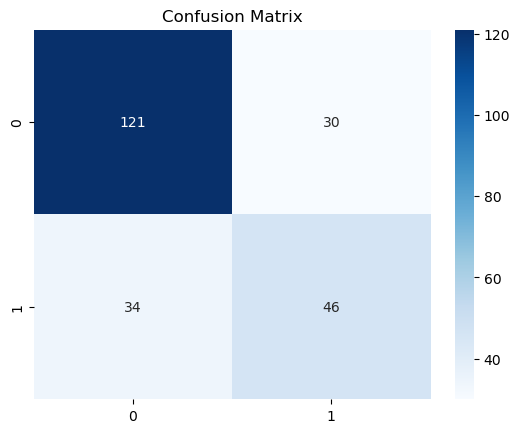

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Load Dataset
df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv")
X = df[['Glucose','BMI','Age','BloodPressure']]
y = df['Outcome']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     998.1
Date:                Sun, 12 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:22:59   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1333   BIC:                         2.714e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.21e+04    941.984    -12.848      0.0

/var/folders/yb/whx8945s5njbtn9r4cvptpd80000gn/T/ipykernel_52983/2264609624.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


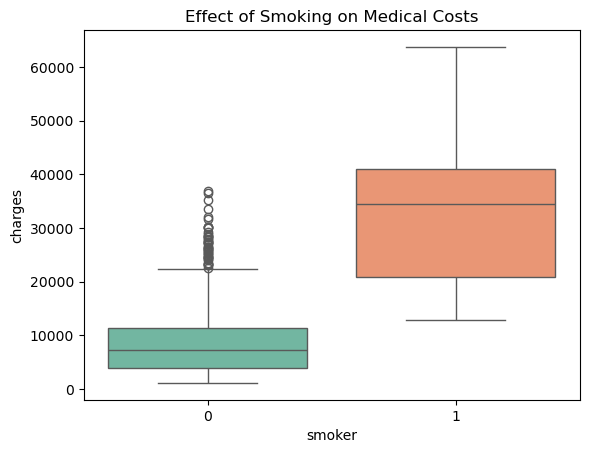

In [16]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Load dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Encode categorical variables
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

# Multiple Linear Regression
X = df[['age', 'bmi', 'smoker', 'children']]
y = df['charges']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

# Logistic Regression for High-Cost Prediction
df['high_cost'] = (df['charges'] > df['charges'].median()).astype(int)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(df[['smoker', 'bmi', 'age']], df['high_cost'])
pred = log_model.predict(df[['smoker', 'bmi', 'age']])
print(classification_report(df['high_cost'], pred))
print("ROC-AUC:", roc_auc_score(df['high_cost'], log_model.predict_proba(df[['smoker', 'bmi', 'age']])[:,1]))

sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title("Effect of Smoking on Medical Costs")
plt.show()


In [22]:
import pandas as pd, statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

# Multiple Linear Regression
X = sm.add_constant(df[['age', 'bmi', 'smoker', 'children']])
y = df['charges']
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

# Logistic Regression for High-Cost Classification
df['high_cost'] = (df['charges'] > df['charges'].median()).astype(int)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(df[['smoker', 'bmi', 'age']], df['high_cost'])
pred = log_model.predict(df[['smoker', 'bmi', 'age']])
print(classification_report(df['high_cost'], pred))
print("ROC-AUC:", roc_auc_score(df['high_cost'], log_model.predict_proba(df[['smoker', 'bmi', 'age']])[:,1]))


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     998.1
Date:                Sun, 12 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:33:38   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1333   BIC:                         2.714e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.21e+04    941.984    -12.848      0.0

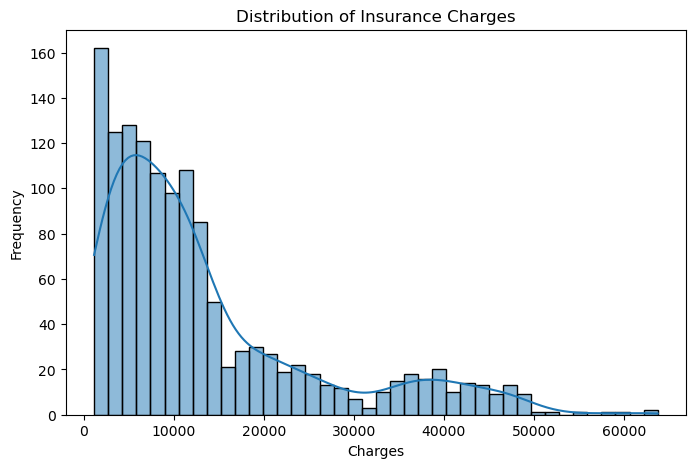

/var/folders/yb/whx8945s5njbtn9r4cvptpd80000gn/T/ipykernel_52983/575328568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


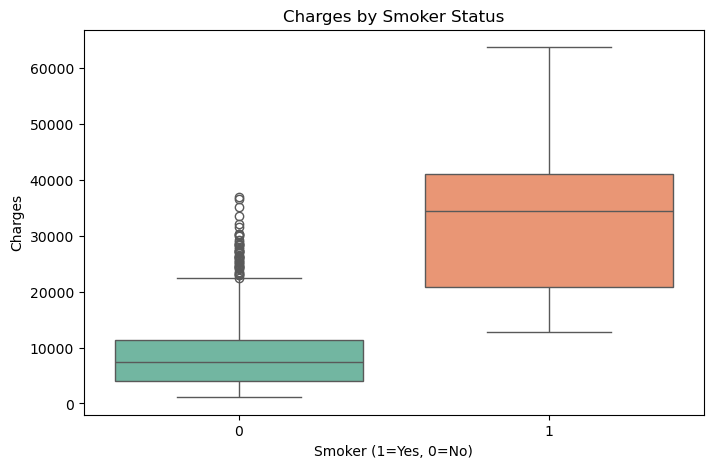

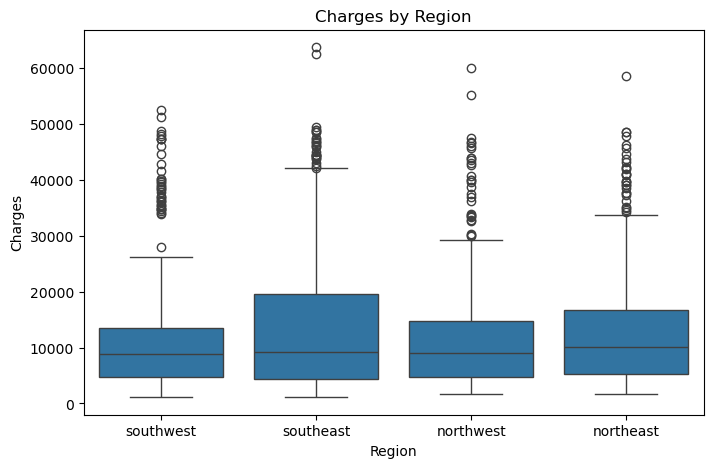

In [23]:
# Distribution of charges
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], bins=40, kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# Charges by smoker status
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Charges by Smoker Status')
plt.xlabel('Smoker (1=Yes, 0=No)')
plt.ylabel('Charges')
plt.show()

# Charges by region
plt.figure(figsize=(8, 5))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()